In [1]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv('links.csv')
df1.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [3]:
df2 = pd.read_csv('movies.csv')
df2.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
df3 = pd.read_csv('ratings.csv')
df3.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# Data cleaning

In [5]:
df1.isnull().sum().sum(), df2.isnull().sum().sum(), df3.isnull().sum().sum()

(8, 0, 0)

In [6]:
df1.dropna(axis=0, inplace=True)

In [7]:
df1.duplicated().sum(), df2.duplicated().sum(), df3.duplicated().sum()

(0, 0, 0)

In [8]:
df = (df1.merge(df2, on='movieId').merge(df3, on='movieId'))
df.rename(columns={'userId_x': 'user_id'}, inplace=True)
df

,movieId,imdbId,tmdbId,title,genres,userId,rating,timestamp
0,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,114709,862.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
...,...,...,...,...,...,...,...,...
100818,193581,5476944,432131.0,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184,4.0,1537109082
100819,193583,5914996,445030.0,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184,3.5,1537109545
100820,193585,6397426,479308.0,Flint (2017),Drama,184,3.5,1537109805
100821,193587,8391976,483455.0,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184,3.5,1537110021


In [9]:
df.drop(['imdbId', 'timestamp', 'movieId', ], axis=1, inplace=True)

In [10]:
df['title'] = [' '.join(x[:-1]) for x in df['title'].str.split()]

In [11]:
df = df[df['title'] != '']

In [17]:
df.groupby(['userId'])['title'].value_counts().reset_index()

,userId,title,count
0,1,"13th Warrior, The",1
1,1,20 Dates,1
2,1,"Abyss, The",1
3,1,"Adventures of Robin Hood, The",1
4,1,Alice in Wonderland,1
...,...,...,...
100449,610,[REC],1
100450,610,[REC]²,1
100451,610,[REC]³ 3 Génesis,1
100452,610,xXx,1


In [16]:
df.drop_duplicates(['userId', 'title'], inplace=True)

# eda

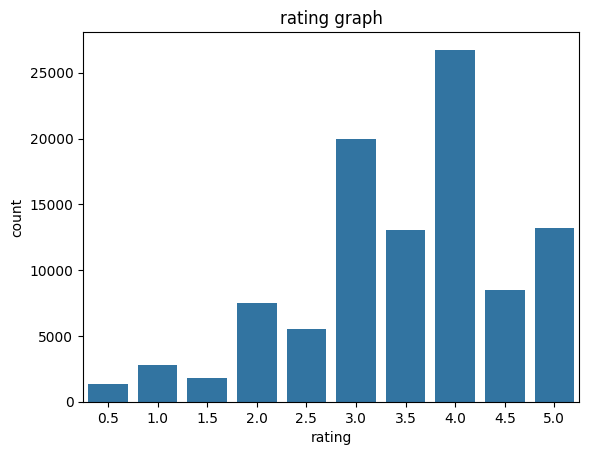

In [18]:
plt.title('rating graph')
sns.countplot(x=df['rating'], data=df);

In [22]:
# count each user rating for movie
df.groupby(['userId'])['title'].count()

userId
1       229
2        29
3        38
4       216
5        44
       ... 
606    1104
607     187
608     825
609      37
610    1298
Name: title, Length: 610, dtype: int64

In [23]:
# count of rating each movie
df.groupby(['title'])['rating'].count()

title
'71                                    1
'Hellboy': The Seeds of Creation       1
'Round Midnight                        2
'Salem's Lot                           1
'Til There Was You                     2
                                      ..
eXistenZ                              22
xXx                                   24
xXx: State of the Union                5
¡Three Amigos!                        26
À nous la liberté (Freedom for Us)     1
Name: rating, Length: 9438, dtype: int64

In [24]:
# count of each movie's
df['title'].value_counts()

title
Forrest Gump                                     329
Shawshank Redemption, The                        317
Pulp Fiction                                     307
Silence of the Lambs, The                        279
Matrix, The                                      278
                                                ... 
San Francisco                                      1
Vampire Hunter D                                   1
Common Thread, A (a.k.a. Sequins) (Brodeuses)      1
Cocoanuts, The                                     1
Andrew Dice Clay: Dice Rules                       1
Name: count, Length: 9438, dtype: int64

In [25]:
df['genres'] = df['genres'].apply(lambda x : x.replace('|', ' '))

In [26]:
df['genres'] = df['genres'].str.lower()

# popular movies

In [27]:
# num of rating for each movie's
num_rating_df = df.groupby(['title']).count()['rating'].reset_index()
num_rating_df.rename(columns={'rating' : 'num_rating'}, inplace=True)
num_rating_df

,title,num_rating
0,'71,1
1,'Hellboy': The Seeds of Creation,1
2,'Round Midnight,2
3,'Salem's Lot,1
4,'Til There Was You,2
...,...,...
9433,eXistenZ,22
9434,xXx,24
9435,xXx: State of the Union,5
9436,¡Three Amigos!,26


In [28]:
# average rating for each movie
avg_rating_df = df.groupby('title')['rating'].mean().reset_index()
avg_rating_df.rename(columns={'rating' : 'avg_rating'}, inplace=True)
avg_rating_df

,title,avg_rating
0,'71,4.000000
1,'Hellboy': The Seeds of Creation,4.000000
2,'Round Midnight,3.500000
3,'Salem's Lot,5.000000
4,'Til There Was You,4.000000
...,...,...
9433,eXistenZ,3.863636
9434,xXx,2.770833
9435,xXx: State of the Union,2.000000
9436,¡Three Amigos!,3.134615


In [29]:
# merge num_rating_df + avg_rating_df
popular_df = num_rating_df.merge(avg_rating_df, on='title')
popular_df

,title,num_rating,avg_rating
0,'71,1,4.000000
1,'Hellboy': The Seeds of Creation,1,4.000000
2,'Round Midnight,2,3.500000
3,'Salem's Lot,1,5.000000
4,'Til There Was You,2,4.000000
...,...,...,...
9433,eXistenZ,22,3.863636
9434,xXx,24,2.770833
9435,xXx: State of the Union,5,2.000000
9436,¡Three Amigos!,26,3.134615


In [39]:
#Number of rating >= 100
popular_df = popular_df[popular_df['num_rating'] >= 100].sort_values('avg_rating', ascending=False).head(50)

In [40]:
# merge with main dataframe 
popular_df = popular_df.merge(df, on='title').drop_duplicates('title')[['title', 'num_rating', 'avg_rating', 'tmdbId']]

In [41]:
# sort according to number of rating
popular_df = popular_df.sort_values('num_rating', ascending=False)

In [43]:
popular_df

,title,num_rating,avg_rating,tmdbId
3771,Forrest Gump,329,4.164134,13.0
0,"Shawshank Redemption, The",317,4.429022,278.0
3066,Pulp Fiction,307,4.197068,680.0
4236,"Silence of the Lambs, The",279,4.161290,274.0
3373,"Matrix, The",278,4.192446,603.0
1684,Star Wars: Episode IV - A New Hope,251,4.231076,11.0
7308,Braveheart,237,4.031646,197.0
1935,Schindler's List,220,4.225000,424.0
509,Fight Club,218,4.272936,550.0
2391,Star Wars: Episode V - The Empire Strikes Back,211,4.215640,1891.0


# collaborative based recommendation

# item based

In [74]:
# user's rating on movie's greater than 40
x = df.groupby(['userId']).count()['title'] > 40
high_rated_user = x[x].index

In [75]:
# select high rated user's
user_rated_df = df[df['userId'].isin(high_rated_user)]
user_rated_df

,tmdbId,title,genres,userId,rating
0,862.0,Toy Story,adventure animation children comedy fantasy,1,4.0
1,862.0,Toy Story,adventure animation children comedy fantasy,5,4.0
2,862.0,Toy Story,adventure animation children comedy fantasy,7,4.5
3,862.0,Toy Story,adventure animation children comedy fantasy,15,2.5
4,862.0,Toy Story,adventure animation children comedy fantasy,17,4.5
...,...,...,...,...,...
100818,432131.0,Black Butler: Book of the Atlantic,action animation comedy fantasy,184,4.0
100819,445030.0,No Game No Life: Zero,animation comedy fantasy,184,3.5
100820,479308.0,Flint,drama,184,3.5
100821,483455.0,Bungo Stray Dogs: Dead Apple,action animation,184,3.5


In [85]:
# movie's rating greater than 30
y = df.groupby(['title']).count()['rating'] > 30
high_rated_movies = y[y].index

In [87]:
# higest movie rated and user rated
filtered_df = user_rated_df[user_rated_df['title'].isin(high_rated_movies)]

In [88]:
filtered_df = filtered_df.reset_index(drop=True)

create pivot table 

In [90]:
pivot_item_based = filtered_df.pivot_table(columns='userId', index='title', values='rating')
pivot_item_based

userId,1,4,5,6,7,8,9,10,11,14,...,600,601,602,603,604,605,606,607,608,610
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5
10 Things I Hate About You,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,3.0,NaN,5.0,NaN,NaN,NaN,NaN
101 Dalmatians,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,4.0,NaN,3.0,NaN,NaN,NaN,NaN
101 Dalmatians (One Hundred and One Dalmatians),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12 Angry Men,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Young Frankenstein,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,5.0,NaN,NaN,3.5,NaN,NaN,NaN
Zodiac,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
Zombieland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5


In [91]:
#fill nun value from 0
pivot_item_based.fillna(0, inplace=True)

In [92]:
pivot_item_based

userId,1,4,5,6,7,8,9,10,11,14,...,600,601,602,603,604,605,606,607,608,610
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5
10 Things I Hate About You,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0.0,0.0
101 Dalmatians,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0
101 Dalmatians (One Hundred and One Dalmatians),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12 Angry Men,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Young Frankenstein,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,5.0,0.0,0.0,3.5,0.0,0.0,0.0
Zodiac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
Zombieland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5


In [93]:
# similarity score 
similarity_item = cosine_similarity(pivot_item_based)
similarity_item

array([[1.        , 0.30337076, 0.20335525, ..., 0.43327183, 0.31558869,
        0.29423389],
       [0.30337076, 1.        , 0.29758817, ..., 0.25677098, 0.36763856,
        0.13107518],
       [0.20335525, 0.29758817, 1.        , ..., 0.20289154, 0.26422388,
        0.12991666],
       ...,
       [0.43327183, 0.25677098, 0.20289154, ..., 1.        , 0.37313325,
        0.39296451],
       [0.31558869, 0.36763856, 0.26422388, ..., 0.37313325, 1.        ,
        0.18109627],
       [0.29423389, 0.13107518, 0.12991666, ..., 0.39296451, 0.18109627,
        1.        ]])

In [115]:
# movie reccomend on item based
def recommend_item_based(movie_name):
    if movie_name not in pivot_item_based.index:
        return 'not found movie'
        
    # movie index
    movie_index = np.where(pivot_item_based.index == movie_name)[0][0]
    # 5 high similarity score
    similar_item = sorted(list(enumerate(similarity_item[movie_index])), key=lambda x: x[1], reverse=True)[1:6]
    l  = []
    for i in similar_item:
        print(pivot_item_based.index[i[0]])


In [116]:
recommend_item_based('Toy Story')

Jurassic Park
Toy Story 2
Forrest Gump
Star Wars: Episode IV - A New Hope
Lion King, The


# user based

transform pivot table for user based recommendation

In [117]:
pivot_user_based = pivot_item_based.T
pivot_user_based

title,(500) Days of Summer,10 Things I Hate About You,101 Dalmatians,101 Dalmatians (One Hundred and One Dalmatians),12 Angry Men,2001: A Space Odyssey,28 Days Later,300,"40-Year-Old Virgin, The",50 First Dates,...,X-Men: First Class,X-Men: The Last Stand,X2: X-Men United,Yes Man,You've Got Mail,Young Frankenstein,Zodiac,Zombieland,Zoolander,Zootopia
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,0.0,5.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
606,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.5,3.5,0.0,0.0,0.0,0.0
607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
# similarity score
similarity_user = cosine_similarity(pivot_user_based)
similarity_user

array([[1.        , 0.31976449, 0.17443517, ..., 0.34891524, 0.40089646,
        0.27715663],
       [0.31976449, 1.        , 0.13385022, ..., 0.22566333, 0.25661905,
        0.21277037],
       [0.17443517, 0.13385022, 1.        , ..., 0.20923407, 0.1859889 ,
        0.11165433],
       ...,
       [0.34891524, 0.22566333, 0.20923407, ..., 1.        , 0.37821029,
        0.25763451],
       [0.40089646, 0.25661905, 0.1859889 , ..., 0.37821029, 1.        ,
        0.54021275],
       [0.27715663, 0.21277037, 0.11165433, ..., 0.25763451, 0.54021275,
        1.        ]])

In [119]:
# unique movie's dataframe
unique_movie_df = pd.DataFrame()
unique_movie_df = df[['tmdbId', 'title', 'genres', 'rating']]
unique_movie_df = unique_movie_df.drop_duplicates(subset=['title'], keep='first')

In [120]:
unique_movie_df.reset_index(inplace=True, drop=True)
unique_movie_df

,tmdbId,title,genres,rating
0,862.0,Toy Story,adventure animation children comedy fantasy,4.0
1,8844.0,Jumanji,adventure children fantasy,4.0
2,15602.0,Grumpier Old Men,comedy romance,4.0
3,31357.0,Waiting to Exhale,comedy drama romance,3.0
4,11862.0,Father of the Bride Part II,comedy,5.0
...,...,...,...,...
9433,432131.0,Black Butler: Book of the Atlantic,action animation comedy fantasy,4.0
9434,445030.0,No Game No Life: Zero,animation comedy fantasy,3.5
9435,479308.0,Flint,drama,3.5
9436,483455.0,Bungo Stray Dogs: Dead Apple,action animation,3.5


In [122]:
from sentence_transformers import SentenceTransformer
import faiss

ERROR! Session/line number was not unique in database. History logging moved to new session 1660


In [123]:
# Load hugging face model
model = SentenceTransformer("all-MiniLM-L6-v2")

In [124]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [125]:
# generate embedding for genre's
genre_embedding = model.encode(unique_movie_df['genres']).astype('float32')

In [128]:
faiss.normalize_L2(genre_embedding)
genre_faiss_database = faiss.IndexFlatIP(genre_embedding.shape[1])
genre_faiss_database.add(genre_embedding)

In [129]:
genre_embedding

array([[-0.02071082,  0.0178222 , -0.02619914, ...,  0.01847934,
        -0.00389409, -0.02552311],
       [ 0.01627532,  0.04601659,  0.00526148, ...,  0.03232856,
        -0.08034895, -0.01181443],
       [-0.05460748, -0.07671201, -0.0194611 , ...,  0.00203723,
         0.09276047, -0.10156585],
       ...,
       [ 0.01184697, -0.02681721,  0.01259556, ...,  0.02914641,
         0.02256265, -0.00765837],
       [-0.06338071, -0.04692075, -0.02633433, ..., -0.02430074,
        -0.00768804, -0.00221391],
       [-0.04261126, -0.04620109, -0.03457102, ...,  0.0121217 ,
         0.08591416, -0.00685261]], dtype=float32)

In [265]:
# movie recommend on user behavior
def recommend_user_based(user):
    
    #for new users
    if user not in pivot_user_based.index:
        print('Your are new user ')

        print('Popular Movies : \n ', popular_df['title'].head(10).tolist())
        
        select_genre = input('''Select your favorite/mood -> 
                advanture  animation  comedy  romance
                drama      action     crime   horror
                mystery    thriller   hildren sci-fi
                fantasy    war        documentary
                : ''')
    
        select_genre = select_genre.lower()
        split_genre = select_genre.split()
        movies_list_1 = []
        
        # display unique genre movies
        for i in split_genre:
            movies_list_1.append(unique_movie_df[unique_movie_df['genres'] == i].sort_values('rating', ascending=False).head(5)['title'].tolist())

        # display both genre movies
        emb = model.encode([select_genre])
        d, i = genre_faiss_database.search(emb, k=5)
        movies_list_1.append(unique_movie_df['title'].loc[i[0]].tolist())

        return movies_list_1

    # for regular user
    else:
        movie_index = np.where(pivot_user_based.index == user)[0][0]
        similar_user = sorted(list(enumerate(similarity_user[movie_index])), key=lambda x: x[1], reverse=True)[1:6]
        movies_list_2 = []
        for i in similar_user:
            movies_list_2.append(pivot_user_based.columns[i[0]])
            
        return movies_list_2
  

In [266]:
recommend_user_based(2)

Your are new user 
Popular Movies : 
  ['Forrest Gump', 'Shawshank Redemption, The', 'Pulp Fiction', 'Silence of the Lambs, The', 'Matrix, The', 'Star Wars: Episode IV - A New Hope', 'Braveheart', "Schindler's List", 'Fight Club', 'Star Wars: Episode V - The Empire Strikes Back']


Select your favorite/mood -> 
                advanture  animation  comedy  romance
                drama      action     crime   horror
                mystery    thriller   hildren sci-fi
                fantasy    war        documentary
                :  fantasy crime


[['Andalusian Dog, An (Chien andalou, Un)',
  'Meshes of the Afternoon',
  'Fantastic Beasts and Where to Find Them',
  "Miss Peregrine's Home for Peculiar Children"],
 ['The Adventures of Sherlock Holmes and Dr. Watson: Bloody Signature',
  'Sherlock Holmes and Dr. Watson: Acquaintance',
  'Sherlock - A Study in Pink',
  "Gridlock'd",
  'General, The'],
 ['Bright',
  'Dark Portals: The Chronicles of Vidocq (Vidocq)',
  'Catwoman',
  'Cabinet of Dr. Caligari, The (Cabinet des Dr. Caligari., Das)',
  'Pitfall (Otoshiana)']]

In [267]:
recommend_user_based(1)

['Iron Giant, The',
 'Eraser',
 'Devil Wears Prada, The',
 'Gone with the Wind',
 "Howl's Moving Castle (Hauru no ugoku shiro)"]

In [140]:
# generate embedding for title
movie_title_embedding = model.encode(unique_movie_df['title'])

In [141]:
faiss.normalize_L2(movie_title_embedding)
search_text_database = faiss.IndexFlatIP(movie_title_embedding.shape[1])
search_text_database.add(movie_title_embedding)

In [256]:
# search movie's function

def search_movie_by_genres(search_genre):
    search_genre = search_genre.lower()
    
    # all possible genre's
    l = ['advanture' ,'animation', 'comedy', 'romance', 'drama', 'action', 'crime', 'horror', 'mystery', 'thriller', 
         'children', 'sci-fi', 'scifi', 'fantasy', 'war', 'documentary']
    
    # search by genre's
    genres_movie_list = []
    combo = ''
    for genre in search_genre.split():
        if genre in l:
            combo += genre + ' '
            embedding = model.encode([genre])
            d, idx = genre_faiss_database.search(embedding, k=5)
            genres_movie_list.append(unique_movie_df.loc[idx[0]].sort_values('rating', ascending=False)['title'].tolist())
    print(combo)
    combo_embedding = model.encode([combo])
    d, i = genre_faiss_database.search(combo_embedding, k=5)
    genres_movie_list.append(unique_movie_df.loc[i[0]].sort_values('rating', ascending=False)['title'].tolist())
    return genres_movie_list
  
    
def search_moveie_by_name(search_movie):
    search_movie = search_movie.lower()
    searching_movie_list = []

    search_embedding = model.encode([search_movie])
    d, idx = search_text_database.search(search_embedding, k=5)
    
    searching_movie_list.append(unique_movie_df.loc[idx[0]].sort_values('rating', ascending=False)['title'].tolist())
    return searching_movie_list

In [257]:
search_moveie_by_name('Spider mAn')

[['Spider-Man 2',
  'Spider-Man',
  'Spider-Man 3',
  'Amazing Spider-Man, The',
  'The Amazing Spider-Man 2']]

In [258]:
search_movie_by_genres('comedy war action drama movies')

comedy war action drama 


[['Father of the Bride Part II',
  'Four Rooms',
  'Friday',
  'Bio-Dome',
  'Ace Ventura: When Nature Calls'],
 ['Battle for Haditha',
  'Run Silent Run Deep',
  'Objective, Burma!',
  'Pork Chop Hill',
  'Iron Eagle II'],
 ['Sudden Death',
  'Bloodsport 2 (a.k.a. Bloodsport II: The Next Kumite)',
  'Hunted, The',
  'Under Siege 2: Dark Territory',
  'Fair Game'],
 ['Restoration',
  'Othello',
  'Nixon',
  'Cry, the Beloved Country',
  'Dangerous Minds'],
 ['Tea with Mussolini',
  'Mister Roberts',
  'And Starring Pancho Villa as Himself',
  'Great Dictator, The',
  'To Be or Not to Be']]

In [193]:
import joblib

In [194]:
joblib.dump(popular_df, 'popular_movie.pkl')
joblib.dump(similarity_item, 'item_based.pkl')
joblib.dump(similarity_user, 'user_based.pkl')
joblib.dump(unique_movie_df, 'movie_data.pkl')
joblib.dump(pivot_item_based, 'pivot_item.pkl')
joblib.dump(pivot_user_based, 'pivot_user.pkl')
model.save_pretrained('./collaborative_system')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [195]:
joblib.dump(genre_faiss_database, 'genre_database.pkl')
joblib.dump(search_text_database, 'search_text_database.pkl')

['search_text_database.pkl']

In [197]:
joblib.dump(filtered_df, 'all_movies.pkl')

['all_movies.pkl']